In [14]:
import numpy as np
import emcee as mc
import matplotlib.pyplot as plt
from scipy.stats import uniform, norm

In [16]:
transient = np.load('transient.npy')
time = transient[:, 0]
flux = transient[:, 1]
errs = transient[:, 2]

N = len(time)

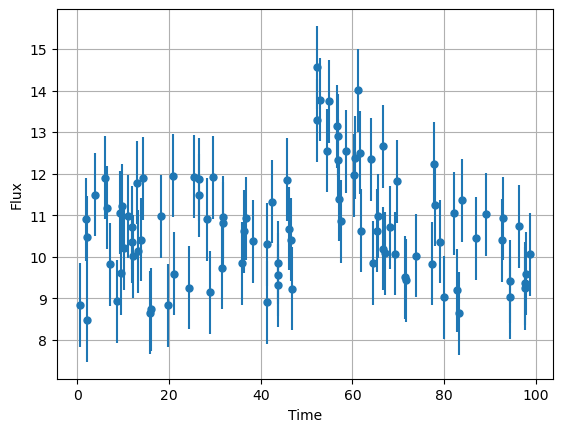

In [12]:
fig, ax = plt.subplots()
plt.errorbar(x=time, y=flux, yerr=errs, fmt='o', markersize=5)
plt.xlabel('Time')
plt.ylabel('Flux')
plt.grid()

In [13]:
def model(t, b, t0, A, alpha):
    
    if t < t0:
        y = b
    
    else: 
        y = b + A*np.exp(-alpha*(t-t0))

    return y

In [22]:
def lik(x, data, err):
    
    init_lik = np.ones(len(x)) 
    
    for i in range(len(data)):
        this_lik = norm.pdf(x, data[i], err[i]) 
        init_lik = init_lik * this_lik

    return init_lik

In [24]:
def prior_b(x):
    # x between 0 and 50
    return 1/50

def prior_A(x):
    # x between 0 and 50
    return 1/50

def prior_t0(x):
    # x between 0 and 100
    return 1/100

def prior_logalpha(x):
    # x between -5 and 5
    return 1/10

def tot_prior(x):
    return prior_b(x) * prior_A(x) * prior_t0(x) * prior_logalpha(x)

def tot_post(x, data, err):
    # posterior = likelihood * prior
    return lik(x, data, err) * tot_prior(x)

def log_post(x, data, err):
    return np.log(tot_post(x, data, err))

In [ ]:
nsamp = 10000
nparam = 4
nwalkers = 5
